# Daily weather pipeline — walkthrough

Daily weather for five cities from the [Open-Meteo archive API](https://open-meteo.com/en/docs/historical-weather-api),
extracted, loaded, modelled with dbt and orchestrated by Airflow.

**This notebook does not re-implement anything.** Every cell imports from the `pipelines`
package, which is exactly what the Airflow DAG in `dags/weather_pipeline.py` calls. If a
cell here works, the DAG task works.

| Stage | Code | What it does |
|---|---|---|
| Extract | `pipelines.extract` | One API call per city for **one logical date**, landed as JSON |
| Load | `pipelines.load` | Delete-then-insert that date's rows into `raw.weather_daily` |
| Transform | `pipelines.dbt_runner` → `dbt/weather` | `stg_weather_daily` (view) → two marts (tables) |
| Test | `pipelines.dbt_runner` | dbt schema tests + singular data tests |
| Orchestrate | `dags/weather_pipeline.py` | `extract → load → dbt run → dbt test`, daily, with catchup |

**The warehouse is DuckDB** — a single file under `data/warehouse/`. That removes a database
service from the critical path, so this notebook runs identically on a laptop, in the
container and in CI. The SQL and the idempotency strategy are the same ones you would write
against Postgres.

Contents:
1. [Extract](#1) · 2. [Load](#2) · 3. [Re-run safety](#3) · 4. [Backfill 30 days](#4) ·
5. [dbt run](#5) · 6. [dbt test](#6) · 7. [What the mart says](#7) · 8. [The DAG](#8)

### Setup

Add the repo root to `sys.path` so `pipelines` imports whether the kernel started in `notebooks/` or at the repo root.

In [1]:
import subprocess
import sys
import textwrap
from datetime import date, timedelta
from pathlib import Path

import duckdb
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pipelines import CITIES, settings
from pipelines.dbt_runner import dbt_run, dbt_test
from pipelines.extract import extract_weather, target_date_for, write_landing
from pipelines.load import load_weather, load_from_landing
from pipelines.warehouse import connect

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

def q(sql: str) -> pd.DataFrame:
    """Run a read-only query against the warehouse and return a DataFrame."""
    with connect(read_only=True) as con:
        return con.execute(sql).df()

print(f"project root : {PROJECT_ROOT}")
print(f"warehouse    : {settings.warehouse_path}")
print(f"landing dir  : {settings.landing_dir}")
print(f"dbt project  : {settings.dbt_project_dir}")
print(f"archive lag  : {settings.archive_lag_days} days")
print(f"cities       : {', '.join(c.name for c in CITIES)}")

project root : /home/himadri/Projects/assessment_de_20260910_HimadriRajora
warehouse    : /home/himadri/Projects/assessment_de_20260910_HimadriRajora/data/warehouse/weather.duckdb
landing dir  : /home/himadri/Projects/assessment_de_20260910_HimadriRajora/data/landing
dbt project  : /home/himadri/Projects/assessment_de_20260910_HimadriRajora/dbt/weather
archive lag  : 5 days
cities       : Berlin, London, New York, Tokyo, Sydney


### A clean slate

Deleting the warehouse first means everything below is built from nothing during this run —
no state left over from an earlier execution can flatter the results.

In [2]:
if settings.warehouse_path.exists():
    settings.warehouse_path.unlink()
for stale in settings.landing_dir.glob("*.json"):
    stale.unlink()

print("warehouse exists:", settings.warehouse_path.exists())
print("landed files    :", len(list(settings.landing_dir.glob("*.json"))))

warehouse exists: False
landed files    : 0


<a id="1"></a>
## 1. Extract

**One run = one logical date.** A run for logical date *D* fetches weather for
*D − ARCHIVE_LAG_DAYS* (default 5), because the archive endpoint trails real time by a few
days. `target_date_for()` is the single place that mapping lives, so the DAG, the CLI and
this notebook can never disagree about which day a run owns.

Two deliberate choices:

* **We call the JSON endpoint, not the `openmeteo_requests` flatbuffer SDK.** The SDK decodes
  straight into numpy arrays, which means the payload is already transformed before it reaches
  the raw table. The brief asks for API fields stored unmodified, so we keep the JSON.
* **`timezone=UTC` is pinned.** Otherwise "a day" would mean something different per city and
  a re-run could shift a row onto a different date.

In [3]:
LOGICAL_DATE = date.today()
TARGET_DATE = target_date_for(LOGICAL_DATE)

print(f"logical date (what Airflow passes) : {LOGICAL_DATE}")
print(f"target weather date (logical - {settings.archive_lag_days}d)  : {TARGET_DATE}")

records = extract_weather(TARGET_DATE)
print(f"\nrecords returned: {len(records)}  ({len(CITIES)} cities x 1 day)")

pd.DataFrame(records)[["city_id", "city_name", "country_code", "weather_date", "_batch_id"]]

logical date (what Airflow passes) : 2026-09-10
target weather date (logical - 5d)  : 2026-09-05



records returned: 5  (5 cities x 1 day)


,city_id,city_name,country_code,weather_date,_batch_id
0,berlin,Berlin,DE,2026-09-05,2026-09-05
1,london,London,GB,2026-09-05,2026-09-05
2,new_york,New York,US,2026-09-05,2026-09-05
3,tokyo,Tokyo,JP,2026-09-05,2026-09-05
4,sydney,Sydney,AU,2026-09-05,2026-09-05


Each record carries the API's own fields, untouched. Here is one row's payload and the response metadata that came with it:

In [4]:
import json

sample = records[0]
print("payload  (API daily fields, verbatim):")
print(json.dumps(json.loads(sample["payload"]), indent=2))
print("\napi_meta (response-level fields, verbatim):")
print(json.dumps(json.loads(sample["api_meta"]), indent=2))

payload  (API daily fields, verbatim):
{
  "precipitation_sum": 9.1,
  "temperature_2m_max": 20.0,
  "temperature_2m_mean": 16.1,
  "temperature_2m_min": 14.0,
  "time": "2026-09-05",
  "wind_speed_10m_max": 27.3
}

api_meta (response-level fields, verbatim):
{
  "daily_units": {
    "precipitation_sum": "mm",
    "temperature_2m_max": "\u00b0C",
    "temperature_2m_mean": "\u00b0C",
    "temperature_2m_min": "\u00b0C",
    "time": "iso8601",
    "wind_speed_10m_max": "km/h"
  },
  "elevation": 38.0,
  "generationtime_ms": 4.807233810424805,
  "latitude": 52.54833,
  "longitude": 13.407822,
  "timezone": "GMT",
  "timezone_abbreviation": "GMT",
  "utc_offset_seconds": 0
}


The records are landed on disk before loading. The filename is derived from the weather date, so a re-run overwrites its own file instead of accumulating a pile of near-identical extracts.

In [5]:
landed = write_landing(records, TARGET_DATE)
print(f"landed file : {landed.relative_to(PROJECT_ROOT)}")
print(f"size        : {landed.stat().st_size:,} bytes")

landed file : data/landing/weather_2026-09-05.json
size        : 4,228 bytes


<a id="2"></a>
## 2. Load

The raw table keeps the API fields as JSON, plus our own keys (`city_id`, `weather_date`) and
processing metadata prefixed with `_`. Loading is **delete-then-insert on the run's partition
key**, inside a single transaction: the run owns one weather date, so it deletes that date's
rows and re-inserts them. Nothing else in the table is touched.

That is the whole idempotency story, and it is why retries, manual re-runs and backfills are
all safe.

In [6]:
result = load_weather(records, TARGET_DATE)
print(result)

q(f"""
    select city_id, city_name, weather_date,
           payload ->> 'temperature_2m_mean' as temperature_2m_mean,
           _batch_id, _loaded_at
    from {settings.raw_relation}
    order by city_id
""")

load 2026-09-05: deleted=0 inserted=5 table_total=5


,city_id,city_name,weather_date,temperature_2m_mean,_batch_id,_loaded_at
0,berlin,Berlin,2026-09-05,16.1,2026-09-05,2026-09-10 18:43:03.763689
1,london,London,2026-09-05,17.3,2026-09-05,2026-09-10 18:43:03.763689
2,new_york,New York,2026-09-05,23.2,2026-09-05,2026-09-10 18:43:03.763689
3,sydney,Sydney,2026-09-05,21.9,2026-09-05,2026-09-10 18:43:03.763689
4,tokyo,Tokyo,2026-09-05,22.4,2026-09-05,2026-09-10 18:43:03.763689


<a id="3"></a>
## 3. Re-run safety, proved

Load the same date a second time and count the rows. If the loader appended instead of
replacing, the count would double.

In [7]:
before = q(f"select count(*) as rows from {settings.raw_relation}").loc[0, "rows"]

second = load_from_landing(TARGET_DATE)   # exactly what an Airflow retry would do

after = q(f"select count(*) as rows from {settings.raw_relation}").loc[0, "rows"]

print(f"rows before second load : {before}")
print(f"second load             : {second}")
print(f"rows after second load  : {after}")
assert before == after, "re-running a date changed the row count!"
print(f"\nOK - re-running {TARGET_DATE} left the row count unchanged at {after}.")

rows before second load : 5
second load             : load 2026-09-05: deleted=5 inserted=5 table_total=5
rows after second load  : 5

OK - re-running 2026-09-05 left the row count unchanged at 5.


A third run, this time going all the way back to the API rather than replaying the landed file — same result:

In [8]:
load_weather(extract_weather(TARGET_DATE), TARGET_DATE)

q(f"""
    select weather_date, count(*) as rows, count(distinct city_id) as cities
    from {settings.raw_relation}
    group by weather_date
""")

,weather_date,rows,cities
0,2026-09-05,5,5


<a id="4"></a>
## 4. Backfill: the last 30 logical dates

A backfill is just the same run repeated for a range of logical dates — which is precisely
what `airflow backfill create --dag-id weather_pipeline --from-date ... --to-date ...` does
with these functions. Running it here shows the range is loadable in one pass and that the
per-date grain holds across the whole window.

In [9]:
import time

start = time.perf_counter()
loads = []
for offset in range(29, -1, -1):
    logical = date.today() - timedelta(days=offset)
    target = target_date_for(logical)
    loads.append(load_weather(extract_weather(target), target))

elapsed = time.perf_counter() - start
print(f"backfilled {len(loads)} logical dates in {elapsed:,.1f}s")
print(f"rows inserted: {sum(l.rows_inserted for l in loads)}")

pd.DataFrame(
    [
        {
            "weather_date": l.weather_date,
            "deleted": l.rows_deleted,
            "inserted": l.rows_inserted,
            "table_total": l.total_rows_in_table,
        }
        for l in loads
    ]
).tail(8)

backfilled 30 logical dates in 33.3s
rows inserted: 150


,weather_date,deleted,inserted,table_total
22,2026-08-29,0,5,120
23,2026-08-30,0,5,125
24,2026-08-31,0,5,130
25,2026-09-01,0,5,135
26,2026-09-02,0,5,140
27,2026-09-03,0,5,145
28,2026-09-04,0,5,150
29,2026-09-05,5,5,150


`deleted=5` on the row for the date we loaded in section 2 is the idempotency mechanism at work mid-backfill: that date already existed, so it was replaced rather than duplicated.

In [10]:
q(f"""
    select
        count(*)                     as total_rows,
        count(distinct weather_date) as distinct_dates,
        count(distinct city_id)      as cities,
        min(weather_date)            as first_date,
        max(weather_date)            as last_date
    from {settings.raw_relation}
""")

,total_rows,distinct_dates,cities,first_date,last_date
0,150,30,5,2026-08-07,2026-09-05


<a id="5"></a>
## 5. Transform with dbt

`pipelines.dbt_runner` invokes dbt in-process and returns a typed result, so Airflow can fail
a task precisely rather than parsing stdout. Three models:

* **`staging.stg_weather_daily`** *(view)* — parses the JSON payload into typed, renamed
  columns. It is the only model that knows the API's field names, so an upstream rename is a
  one-file change. A view because it is a thin cast layer: nothing to gain from materialising,
  and it can never go stale.
* **`marts.mart_city_weather_daily`** *(table)* — the daily report per city, enriched with a
  7-day rolling mean and the day-over-day change.
* **`marts.mart_city_weather_summary`** *(table)* — one row per city over the whole window.

Marts are tables because they are what people query. The dataset is tiny (5 cities × 30 days),
so a full rebuild each run is cheaper to run *and* to reason about than an incremental model —
and it means a corrected backfill is reflected immediately.

In [11]:
run_result = dbt_run()
print(run_result.summary())

18:43:38  Running with dbt=1.10.13


18:43:39  Registered adapter: duckdb=1.9.5


18:43:39  Unable to do partial parsing because saved manifest not found. Starting full parse.


18:43:40  Found 3 models, 29 data tests, 1 source, 473 macros


18:43:40  


...

18:43:41  


18:43:41  Completed successfully


18:43:41  


18:43:41  Done. PASS=3 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=3


dbt run: PASS
  success  stg_weather_daily
  success  mart_city_weather_daily
  success  mart_city_weather_summary


In [12]:
q("""
    select table_schema, table_name, table_type
    from information_schema.tables
    where table_schema in ('raw', 'staging', 'marts')
    order by table_schema, table_name
""")

,table_schema,table_name,table_type
0,marts,mart_city_weather_daily,BASE TABLE
1,marts,mart_city_weather_summary,BASE TABLE
2,raw,weather_daily,BASE TABLE
3,staging,stg_weather_daily,VIEW


<a id="6"></a>
## 6. dbt test

Every model and column is tested in `sources.yml`, `stg_weather_daily.yml` and `marts.yml`:

| Test | Catches |
|---|---|
| `unique` on `weather_key` | a loader that appends instead of replacing a date |
| `not_null` on every measurement | a city whose extract came back empty |
| `accepted_values` on `city_id`, `country_code` | a city appearing that nobody configured |
| `relationships` from mart to staging | a mart row with no staging row behind it |

The `unique` test on the grain is the important one. It is what goes red if the load ever
stops being idempotent, which is the assumption everything else here rests on.

In [13]:
test_result = dbt_test()
print(test_result.summary())
print(f"\n{sum(1 for n in test_result.node_results if n['status'] == 'pass')} tests passed, "
      f"{sum(1 for n in test_result.node_results if n['status'] != 'pass')} failed")

18:43:42  Running with dbt=1.10.13


18:43:42  Registered adapter: duckdb=1.9.5


18:43:42  Found 3 models, 29 data tests, 1 source, 473 macros


18:43:42  


18:43:42  Concurrency: 4 threads (target='dev')


...

18:43:43  


18:43:43  Completed successfully


18:43:43  


18:43:43  Done. PASS=29 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=29


dbt test: PASS
  pass     accepted_values_stg_weather_daily_city_id__berlin__london__new_york__tokyo__sydney
  pass     not_null_mart_city_weather_daily_is_rainy_day
  pass     accepted_values_stg_weather_daily_country_code__DE__GB__US__JP__AU
  pass     not_null_mart_city_weather_daily_city_id
  pass     not_null_mart_city_weather_daily_temperature_mean_c
  pass     not_null_mart_city_weather_daily_weather_date
  pass     not_null_mart_city_weather_daily_weather_key
  pass     not_null_mart_city_weather_summary_avg_temperature_c
  pass     not_null_mart_city_weather_summary_city_id
  pass     not_null_mart_city_weather_summary_days_observed
  pass     not_null_mart_city_weather_summary_city_name
  pass     not_null_stg_weather_daily_city_id
  pass     not_null_stg_weather_daily_city_name
  pass     not_null_stg_weather_daily_country_code
  pass     not_null_stg_weather_daily_precipitation_mm
  pass     not_null_stg_weather_daily_temperature_max_c
  pass     not_null_stg_weather_daily_

### These tests are not decoration

Passing tests prove nothing unless they can fail. Insert one duplicate row straight into the
raw table -- simulating a loader that appended instead of replacing -- and watch the grain
test go red.

In [14]:
with connect() as con:
    con.execute(f"""
        insert into {settings.raw_relation}
        select * from {settings.raw_relation} limit 1
    """)

broken = dbt_test(select="unique_stg_weather_daily_weather_key")
print(broken.summary())
print("\ndbt reported success:", broken.success)

18:43:44  Running with dbt=1.10.13


18:43:44  Registered adapter: duckdb=1.9.5


18:43:44  Found 3 models, 29 data tests, 1 source, 473 macros


18:43:44  


18:43:44  Concurrency: 4 threads (target='dev')


...

18:43:45    compiled code at target/compiled/weather/models/staging/stg_weather_daily.yml/unique_stg_weather_daily_weather_key.sql


18:43:45  


18:43:45  Done. PASS=0 WARN=0 ERROR=1 SKIP=0 NO-OP=0 TOTAL=1


ERROR:pipelines.dbt_runner:dbt test: FAIL
  fail     unique_stg_weather_daily_weather_key


dbt test: FAIL
  fail     unique_stg_weather_daily_weather_key

dbt reported success: False


Repair the damage the way the pipeline would — by re-running the affected date — and the test goes green again:

In [15]:
repaired_date = q(f"""
    select weather_date
    from {settings.raw_relation}
    group by city_id, weather_date
    having count(*) > 1
    limit 1
""").loc[0, "weather_date"]

# DuckDB hands dates back as pandas Timestamps; the API wants a plain date.
repaired_date = pd.Timestamp(repaired_date).date()

print(f"re-loading {repaired_date} ...")
load_weather(extract_weather(repaired_date), repaired_date)

fixed = dbt_test(select="unique_stg_weather_daily_weather_key")
print(fixed.summary())

re-loading 2026-08-07 ...


18:43:47  Running with dbt=1.10.13


18:43:47  Registered adapter: duckdb=1.9.5


18:43:47  Found 3 models, 29 data tests, 1 source, 473 macros


18:43:47  


...

18:43:47  


18:43:47  Completed successfully


18:43:47  


18:43:47  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=1


dbt test: PASS
  pass     unique_stg_weather_daily_weather_key


In [16]:
final_tests = dbt_test()
passed = sum(1 for n in final_tests.node_results if n["status"] == "pass")
print(f"full test suite: {passed}/{len(final_tests.node_results)} passing, success={final_tests.success}")

18:43:48  Running with dbt=1.10.13


18:43:48  Registered adapter: duckdb=1.9.5


18:43:48  Found 3 models, 29 data tests, 1 source, 473 macros


18:43:48  


18:43:48  Concurrency: 4 threads (target='dev')


...

18:43:49  


18:43:49  Completed successfully


18:43:49  


18:43:49  Done. PASS=29 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=29


full test suite: 29/29 passing, success=True


<a id="7"></a>
## 7. What the mart says

The question a non-technical colleague would actually ask: *which of our cities was warmest,
and where did it rain most?*

In [17]:
q("""
    select
        city_name              as city,
        country_code           as country,
        days_observed          as days,
        avg_temperature_c      as avg_temp_c,
        warmest_day_c,
        coldest_night_c,
        total_precipitation_mm as rain_mm,
        rainy_days,
        rainy_day_pct          as rainy_pct,
        windiest_day_kmh
    from marts.mart_city_weather_summary
    order by avg_temperature_c desc
""")

,city,country,days,avg_temp_c,warmest_day_c,coldest_night_c,rain_mm,rainy_days,rainy_pct,windiest_day_kmh
0,Tokyo,JP,30,26.4,35.9,19.6,272.5,27,90.0,20.3
1,New York,US,30,24.0,35.2,16.9,156.2,26,86.7,21.6
2,London,GB,30,20.5,36.2,11.4,40.0,16,53.3,22.5
3,Berlin,DE,30,19.6,36.1,11.4,59.1,19,63.3,28.7
4,Sydney,AU,30,15.0,31.6,6.6,47.7,20,66.7,36.9


And the daily grain behind it — the last fortnight in the warmest city, with the rolling average and the day-over-day swing:

In [18]:
warmest = q("""
    select city_id, city_name
    from marts.mart_city_weather_summary
    order by avg_temperature_c desc
    limit 1
""")
warmest_id, warmest_name = warmest.loc[0, "city_id"], warmest.loc[0, "city_name"]
print(f"warmest city: {warmest_name}\n")

q(f"""
    select
        weather_date,
        temperature_min_c,
        temperature_mean_c,
        temperature_max_c,
        temperature_mean_7d_avg_c as rolling_7d,
        temperature_mean_change_c as vs_yesterday,
        precipitation_mm,
        is_rainy_day
    from marts.mart_city_weather_daily
    where city_id = '{warmest_id}'
    order by weather_date desc
    limit 14
""")

warmest city: Tokyo



,weather_date,temperature_min_c,temperature_mean_c,temperature_max_c,rolling_7d,vs_yesterday,precipitation_mm,is_rainy_day
0,2026-09-05,20.2,22.4,25.7,24.6,-0.1,1.7,True
1,2026-09-04,20.5,22.5,25.0,24.4,-3.6,33.3,True
2,2026-09-03,22.6,26.1,31.4,25.3,-1.4,7.3,True
3,2026-09-02,25.3,27.5,30.8,25.5,1.8,1.3,True
4,2026-09-01,22.8,25.7,29.7,26.0,1.6,0.7,True
5,2026-08-31,21.8,24.1,26.8,26.7,0.1,0.1,True
6,2026-08-30,21.7,24.0,26.8,27.4,2.8,0.0,False
7,2026-08-29,19.6,21.2,24.0,27.9,-7.2,8.9,True
8,2026-08-28,22.5,28.4,34.9,28.6,1.1,5.8,True
9,2026-08-27,24.5,27.3,31.2,28.4,-3.9,0.8,True


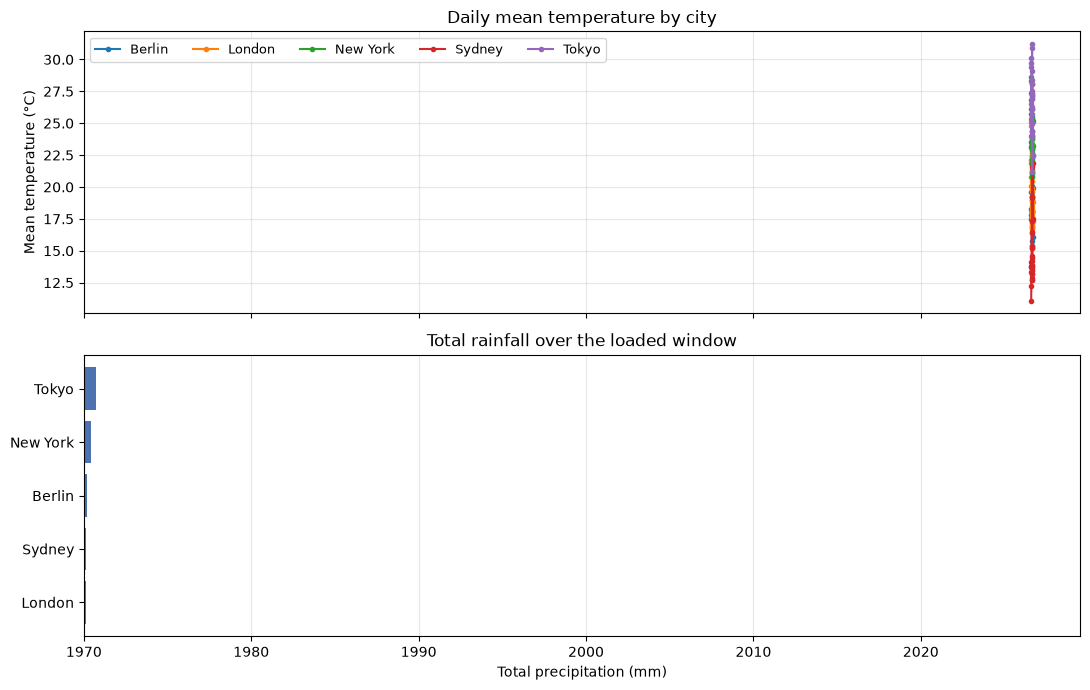

In [19]:
import matplotlib.pyplot as plt

daily = q("""
    select city_name, weather_date, temperature_mean_c, precipitation_mm
    from marts.mart_city_weather_daily
    order by weather_date
""")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for city, group in daily.groupby("city_name"):
    ax1.plot(group["weather_date"], group["temperature_mean_c"], marker="o", ms=3, label=city)
ax1.set_ylabel("Mean temperature (°C)")
ax1.set_title("Daily mean temperature by city")
ax1.legend(loc="upper left", ncol=5, fontsize=9)
ax1.grid(alpha=0.3)

rain = daily.groupby("city_name")["precipitation_mm"].sum().sort_values()
ax2.barh(rain.index, rain.values, color="#4c72b0")
ax2.set_xlabel("Total precipitation (mm)")
ax2.set_title("Total rainfall over the loaded window")
ax2.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. The same code, orchestrated

The DAG is four thin tasks around the functions used above. Parsing it here proves it imports
cleanly and is wired the way we expect: `extract → load → transform (dbt run) → test (dbt test)`,
daily, with catchup on so a backfill replays the range.

In [20]:
import os

os.environ.setdefault("AIRFLOW_HOME", str(PROJECT_ROOT / "airflow_home"))
os.environ["AIRFLOW__CORE__LOAD_EXAMPLES"] = "False"

from airflow.models.dagbag import DagBag

bag = DagBag(str(PROJECT_ROOT / "dags"), include_examples=False)
assert not bag.import_errors, bag.import_errors
dag = bag.dags["weather_pipeline"]

print(f"dag_id          : {dag.dag_id}")
print(f"schedule        : {dag.timetable.summary}")
print(f"catchup         : {dag.catchup}")
print(f"max_active_runs : {dag.max_active_runs}")
print(f"start_date      : {dag.start_date:%Y-%m-%d}")
print("\ntasks:")
for task in dag.topological_sort():
    downstream = ", ".join(sorted(task.downstream_task_ids)) or "-"
    print(f"  {task.task_id:<10} retries={task.retries} retry_delay={task.retry_delay} -> {downstream}")

[2026-09-10T18:43:51.637+0000] {dagbag.py:585} INFO - Filling up the DagBag from /home/himadri/Projects/assessment_de_20260910_HimadriRajora/dags


[2026-09-10T18:43:52.602+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.schemas


[2026-09-10T18:43:52.604+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.tables


[2026-09-10T18:43:52.605+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.types


[2026-09-10T18:43:52.606+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.constraints


...

[2026-09-10T18:43:52.608+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.comments


[2026-09-10T18:43:52.609+0000] {plugins.py:37} INFO - setup plugin alembic.ext.checkconstraint_byname


[2026-09-10T18:43:53.433+0000] {providers_manager.py:953} INFO - The hook_class 'airflow.providers.standard.hooks.filesystem.FSHook' is not fully initialized (UI widgets will be missing), because the 'flask_appbuilder' package is not installed, however it is not required for Airflow components to work


[2026-09-10T18:43:53.436+0000] {providers_manager.py:953} INFO - The hook_class 'airflow.providers.standard.hooks.package_index.PackageIndexHook' is not fully initialized (UI widgets will be missing), because the 'flask_appbuilder' package is not installed, however it is not required for Airflow components to work


dag_id          : weather_pipeline
schedule        : 0 0 * * *
catchup         : True
max_active_runs : 1
start_date      : 2026-08-01

tasks:
  extract    retries=2 retry_delay=0:02:00 -> load
  load       retries=2 retry_delay=0:02:00 -> transform
  transform  retries=2 retry_delay=0:02:00 -> test
  test       retries=2 retry_delay=0:02:00 -> -


And here it is actually running. `airflow dags test` executes the real DAG for one logical
date, in-process, through the scheduler's own code path — so this is the orchestrator doing
extract → load → dbt run → dbt test, not us calling the functions by hand.

It runs against a throwaway `AIRFLOW_HOME` so it cannot collide with the Airflow instance
started by `make up`.

In [21]:
import tempfile

with tempfile.TemporaryDirectory() as tmp_home:
    env = {
        **os.environ,
        "AIRFLOW_HOME": tmp_home,
        "AIRFLOW__CORE__DAGS_FOLDER": str(PROJECT_ROOT / "dags"),
        "AIRFLOW__CORE__LOAD_EXAMPLES": "False",
        "PYTHONPATH": str(PROJECT_ROOT),
    }
    subprocess.run(
        [sys.executable, "-m", "airflow", "db", "migrate"],
        env=env, cwd=PROJECT_ROOT, capture_output=True, text=True, check=True,
    )
    run = subprocess.run(
        [sys.executable, "-m", "airflow", "dags", "test", "weather_pipeline", str(LOGICAL_DATE)],
        env=env, cwd=PROJECT_ROOT, capture_output=True, text=True,
    )

lines = [l for l in run.stdout.splitlines() + run.stderr.splitlines()
         if "DAG TEST" in l or "Dag run" in l or "DagRun Finished" in l]
print("\n".join(lines[-12:]))
print(f"\nexit code: {run.returncode}")
assert run.returncode == 0, "the DAG run failed"

[2026-09-10T18:44:03.960+0000] {dag.py:1230} INFO - [DAG TEST] starting task_id=extract map_index=-1
[2026-09-10T18:44:03.960+0000] {dag.py:1233} INFO - [DAG TEST] running task <TaskInstance: weather_pipeline.extract manual__2026-09-10T18:44:03.927917+00:00 [scheduled]>
[2026-09-10T18:44:06.280+0000] {dag.py:1230} INFO - [DAG TEST] starting task_id=load map_index=-1
[2026-09-10T18:44:06.280+0000] {dag.py:1233} INFO - [DAG TEST] running task <TaskInstance: weather_pipeline.load manual__2026-09-10T18:44:03.927917+00:00 [scheduled]>
[2026-09-10T18:44:07.544+0000] {dag.py:1230} INFO - [DAG TEST] starting task_id=transform map_index=-1
[2026-09-10T18:44:07.545+0000] {dag.py:1233} INFO - [DAG TEST] running task <TaskInstance: weather_pipeline.transform manual__2026-09-10T18:44:03.927917+00:00 [scheduled]>
[2026-09-10T18:44:10.826+0000] {dag.py:1230} INFO - [DAG TEST] starting task_id=test map_index=-1
[2026-09-10T18:44:10.827+0000] {dag.py:1233} INFO - [DAG TEST] running task <TaskInstance: 

In [22]:
q(f"""
    select weather_date, count(*) as rows
    from {settings.raw_relation}
    where weather_date = date '{target_date_for(LOGICAL_DATE)}'
    group by weather_date
""")

,weather_date,rows
0,2026-09-05,5


The DAG re-ran the date this notebook had already loaded, and the row count is still 5 — one
per city. The orchestrated path and the manual path converge on the same state, which is the
property that makes retries and backfills boring.

---

## Recap of the decisions

| Decision | Why |
|---|---|
| One logical date per run | Makes the unit of work small, retryable and backfillable. The date is the partition key the loader deletes on. |
| Extract from the JSON endpoint, not the SDK | Raw API fields reach the raw table unmodified; the SDK would decode them to numpy first. |
| Land to a date-named file before loading | Extract and load fail independently, a re-run overwrites its own file, and there is something to inspect when the API surprises us. |
| Delete-then-insert in one transaction | Idempotency without upsert gymnastics, and no half-written date if the insert fails. |
| Staging as a view, marts as tables | Staging is a thin cast layer; marts are what people query. At this volume a full rebuild beats an incremental model on both cost and clarity. |
| DuckDB as the warehouse | No database service in the critical path, so `make reproduce` behaves the same on a laptop, in the container and in CI. The SQL is portable to Postgres. |
| Testing the grain, not just the columns | `not_null` catches plumbing. The `unique` test on `city_id|weather_date` is what catches the load losing its idempotency, which is the failure that would quietly corrupt every number downstream. |
| Dependencies pinned, including FastAPI/Starlette | Airflow 3.0.4 answers every task start with a 422 against a newer FastAPI stack. Pinning is the difference between this repo working in a year and not. |

### Known gaps

* **Backfill is sequential.** Fine for 30 dates × 5 cities; a wider window wants concurrency
  or a multi-day API call per run.
* **No alerting.** Failures are visible in the Airflow UI and nowhere else.
* **Source freshness** is defined but not wired into a scheduled `dbt source freshness` check.